In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

df = df.drop('duration', axis=1) #duration is not known before the call, so disregard it
#seperating features and target variables
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

print(f"\n Dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Class imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")


 Dataset shape: (41188, 19)
Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64
Class imbalance ratio: 7.88:1


In [3]:
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

print(f"\n  Categorical columns ({len(categorical_cols)}):")
print(categorical_cols.tolist())

print(f"\n Numerical columns ({len(numeric_cols)}):")
print(numeric_cols.tolist())


  Categorical columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

 Numerical columns (9):
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  #using standard scalar because knn is distance based
    ]
)



print("one hot encoding done, standard scalar performed for numerical features")


one hot encoding done, standard scalar performed for numerical features


In [5]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

print("Pipelin made with one hot encoder and standard scalar and the knn model itself. ")

Pipelin made with one hot encoder and standard scalar and the knn model itself. 


In [6]:
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],      # Different K values
    'model__weights': ['uniform', 'distance'],    # Weight function
    'model__metric': ['euclidean', 'manhattan']   # Distance metric
}

print("\n  Hyperparameter Grid:")
print(f"   n_neighbors: {param_grid['model__n_neighbors']}")
print(f"   weights: {param_grid['model__weights']}")
print(f"   metric: {param_grid['model__metric']}")
print(f"\n   Total combinations: {len(param_grid['model__n_neighbors']) * len(param_grid['model__weights']) * len(param_grid['model__metric'])}")



  Hyperparameter Grid:
   n_neighbors: [3, 5, 7, 9, 11]
   weights: ['uniform', 'distance']
   metric: ['euclidean', 'manhattan']

   Total combinations: 20


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print(f"\n  Data split:")
print(f"   Training set: {X_train.shape}")
print(f"   Test set: {X_test.shape}")


  Data split:
   Training set: (32950, 19)
   Test set: (8238, 19)


In [8]:

print("\n Starting GridSearchCV...")
print("   This will train 5-fold CV for each parameter combination")

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1'  #using F1 score due to class imbalance
)

grid_search.fit(X_train, y_train)

print(f"\n Training complete!")
print(f"\n Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param.replace('model__', '')}: {value}")
print(f"\n Best cross-validation F1 score: {grid_search.best_score_:.4f}")


 Starting GridSearchCV...
   This will train 5-fold CV for each parameter combination
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Training complete!

 Best parameters found:
   metric: manhattan
   n_neighbors: 7
   weights: uniform

 Best cross-validation F1 score: 0.3687


In [9]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Predictions made on test set")


 Predictions made on test set


In [10]:
print("\n" + "="*70)
print("MODEL EVALUATION RESULTS")
print("="*70)


accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy: {accuracy:.4f}")


print("\n Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(" Confusion Matrix:")
print(cm)
print("\nBreakdown:")
print(f"   True Negatives (TN):  {cm[0,0]}")
print(f"   False Positives (FP): {cm[0,1]}")
print(f"   False Negatives (FN): {cm[1,0]}")
print(f"   True Positives (TP):  {cm[1,1]}")


tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n Additional Metrics:")
print(f"   Precision (Positive Predictive Value): {precision:.4f}")
print(f"   Recall (Sensitivity/True Positive Rate): {recall:.4f}")
print(f"   Specificity (True Negative Rate): {specificity:.4f}")



MODEL EVALUATION RESULTS

 Accuracy: 0.8929

 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.55      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238

 Confusion Matrix:
[[7090  220]
 [ 662  266]]

Breakdown:
   True Negatives (TN):  7090
   False Positives (FP): 220
   False Negatives (FN): 662
   True Positives (TP):  266

 Additional Metrics:
   Precision (Positive Predictive Value): 0.5473
   Recall (Sensitivity/True Positive Rate): 0.2866
   Specificity (True Negative Rate): 0.9699



 Saved: KNN_confusion_matrix.png


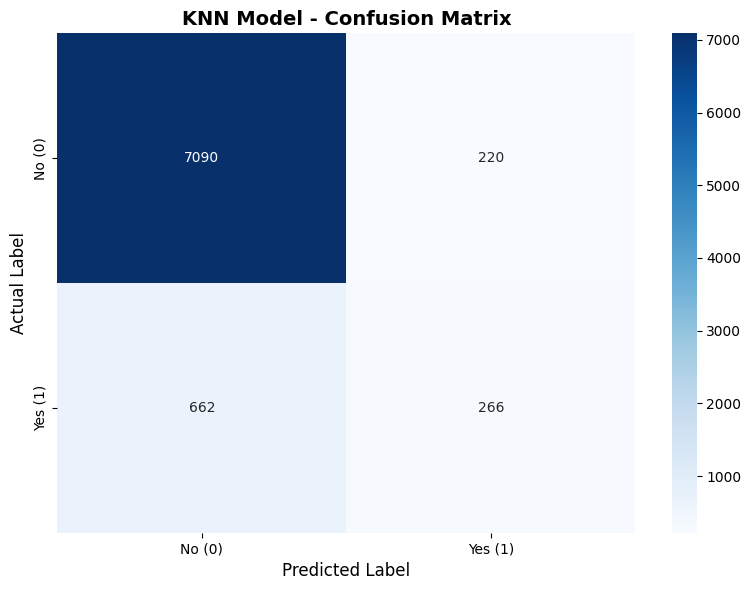

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('KNN Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('output/KNN_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n Saved: KNN_confusion_matrix.png")
plt.show()


In [12]:
print("\n" + "="*70)
print("CROSS-VALIDATION vs TEST SET COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['F1 Score', 'Accuracy'],
    'CV (Training)': [grid_search.best_score_, 'N/A'],
    'Test Set': [f"{2 * precision * recall / (precision + recall):.4f}", f"{accuracy:.4f}"]
})

print("\n", comparison_df.to_string(index=False))



CROSS-VALIDATION vs TEST SET COMPARISON

   Metric CV (Training) Test Set
F1 Score      0.368678   0.3762
Accuracy           N/A   0.8929


##SHAP too computational difficult for KNN due to kernal shap. 